<a href="https://colab.research.google.com/github/alishadaudi/data-science-project-dfw-red-cross-donor-prediction/blob/main/DFW_Red_Cross_Dython_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Code snippet 0
# Installing Dython (for detailed statistical correlations tests and to run significance tests)
!pip install Dython

In [ ]:
# Code snippet 1
# Setting the dataset URL
url = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vQzBYWDif8AqH47QpdaMsxZ0d3aXafgvL6EfnsUk6iN5QPCgrhvEky7hzI16iyfL3L2rfec3QX32JQj/pub?gid=0&single=true&output=csv'

# Display the url
url

'https://docs.google.com/spreadsheets/d/e/2PACX-1vQzBYWDif8AqH47QpdaMsxZ0d3aXafgvL6EfnsUk6iN5QPCgrhvEky7hzI16iyfL3L2rfec3QX32JQj/pub?gid=0&single=true&output=csv'

In [ ]:
# Code snippet 2
# Importing Pandas package for data processing
import pandas as pd

In [ ]:
# Code snippet 3
# Importing the dataset from the URL using pandas package
data = pandas.read_csv(url)

# Display the data
data

,DonorUniqueId,DonorPostalCode,DonorAge,MaritalStatus,GenderIdentity,IsMemberFlag,IsAlumnusFlag,IsParentFlag,HasInvolvementFlag,WealthRating,...,ConsecutiveDonorYears,LastFiscalYearDonation,Donation2FiscalYearsAgo,Donation3FiscalYearsAgo,Donation4FiscalYearsAgo,Donation5FiscalYearsAgo,CurrentFiscalYearDonation,CumulativeDonationAmount,DonorDateOfBirth,DonorIndicatorFlag.
0,1,23187.0,42,Married,Female,N,N,N,N,NaN,...,1,$0,$0,$0,$0,$0,$0,10.0,NaN,Y
1,2,77643.0,33,NaN,Female,N,Y,N,Y,NaN,...,0,$0,$0,$0,$0,$0,$0,2100.0,6/16/1985,Y
2,3,NaN,42,Married,Female,N,N,N,N,NaN,...,1,$0,$0,$0,$0,$0,$200,200.0,NaN,Y
3,4,47141.0,31,NaN,Female,N,Y,N,Y,NaN,...,0,$0,$0,$0,$0,$0,$0,0.0,12/3/1987,N
4,5,92555.0,68,NaN,Female,N,N,N,N,NaN,...,0,$0,$0,$0,$0,$0,$0,505.0,9/11/1950,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34503,34504,7848.0,42,NaN,Female,N,N,N,N,NaN,...,0,$0,$0,$0,$0,$0,$0,0.0,NaN,N
34504,34505,28275.0,24,NaN,Male,N,N,N,N,"$250,000-$499,999",...,0,$0,$0,$0,$0,$0,$0,80.0,9/23/1994,Y
34505,34506,42539.0,27,NaN,Female,N,Y,N,Y,NaN,...,0,$0,$0,$0,$0,$0,$0,0.0,1/3/1991,N
34506,34507,32733.0,46,Married,Female,N,N,N,Y,NaN,...,1,$0,$0,$0,$120,$0,$0,120.0,5/11/1972,Y


In [ ]:
# Code snippet 4
# Displaying the dataset size(rows and columns)
data.shape

(34508, 23)

In [ ]:
# Code snippet 5
# Displaying dataset columns
data.columns

Index(['DonorUniqueId', 'DonorPostalCode', 'DonorAge', 'MaritalStatus',
       'GenderIdentity', 'IsMemberFlag', 'IsAlumnusFlag', 'IsParentFlag',
       'HasInvolvementFlag', 'WealthRating', 'AcademicDegreeLevel',
       'PreferredAddressType', 'HasEmailFlag', 'ConsecutiveDonorYears',
       'LastFiscalYearDonation', 'Donation2FiscalYearsAgo',
       'Donation3FiscalYearsAgo', 'Donation4FiscalYearsAgo',
       'Donation5FiscalYearsAgo', 'CurrentFiscalYearDonation',
       'CumulativeDonationAmount', 'DonorDateOfBirth', 'DonorIndicatorFlag.'],
      dtype='str')

In [ ]:
# Code snippet 6
# Displaying descriptive stats for the numerical variables
data.describe()

,DonorUniqueId,DonorPostalCode,DonorAge,ConsecutiveDonorYears,CumulativeDonationAmount
count,34508.000000,34417.000000,34508.000000,34508.000000,3.450800e+04
mean,17254.500000,56161.625970,43.366987,1.137475,2.363534e+03
std,9961.745881,29966.704506,11.405722,2.423034,1.138014e+05
min,1.000000,211.000000,1.000000,0.000000,0.000000e+00
25%,8627.750000,29927.000000,42.000000,0.000000,0.000000e+00
50%,17254.500000,58108.000000,42.000000,0.000000,2.500000e+01
75%,25881.250000,90265.000000,42.000000,1.000000,1.440000e+02
max,34508.000000,99928.000000,110.000000,36.000000,1.222185e+07


In [ ]:
# Code snippet 7
# Importing missingno package to display missing data proportions
import missingno as msno

<Axes: >

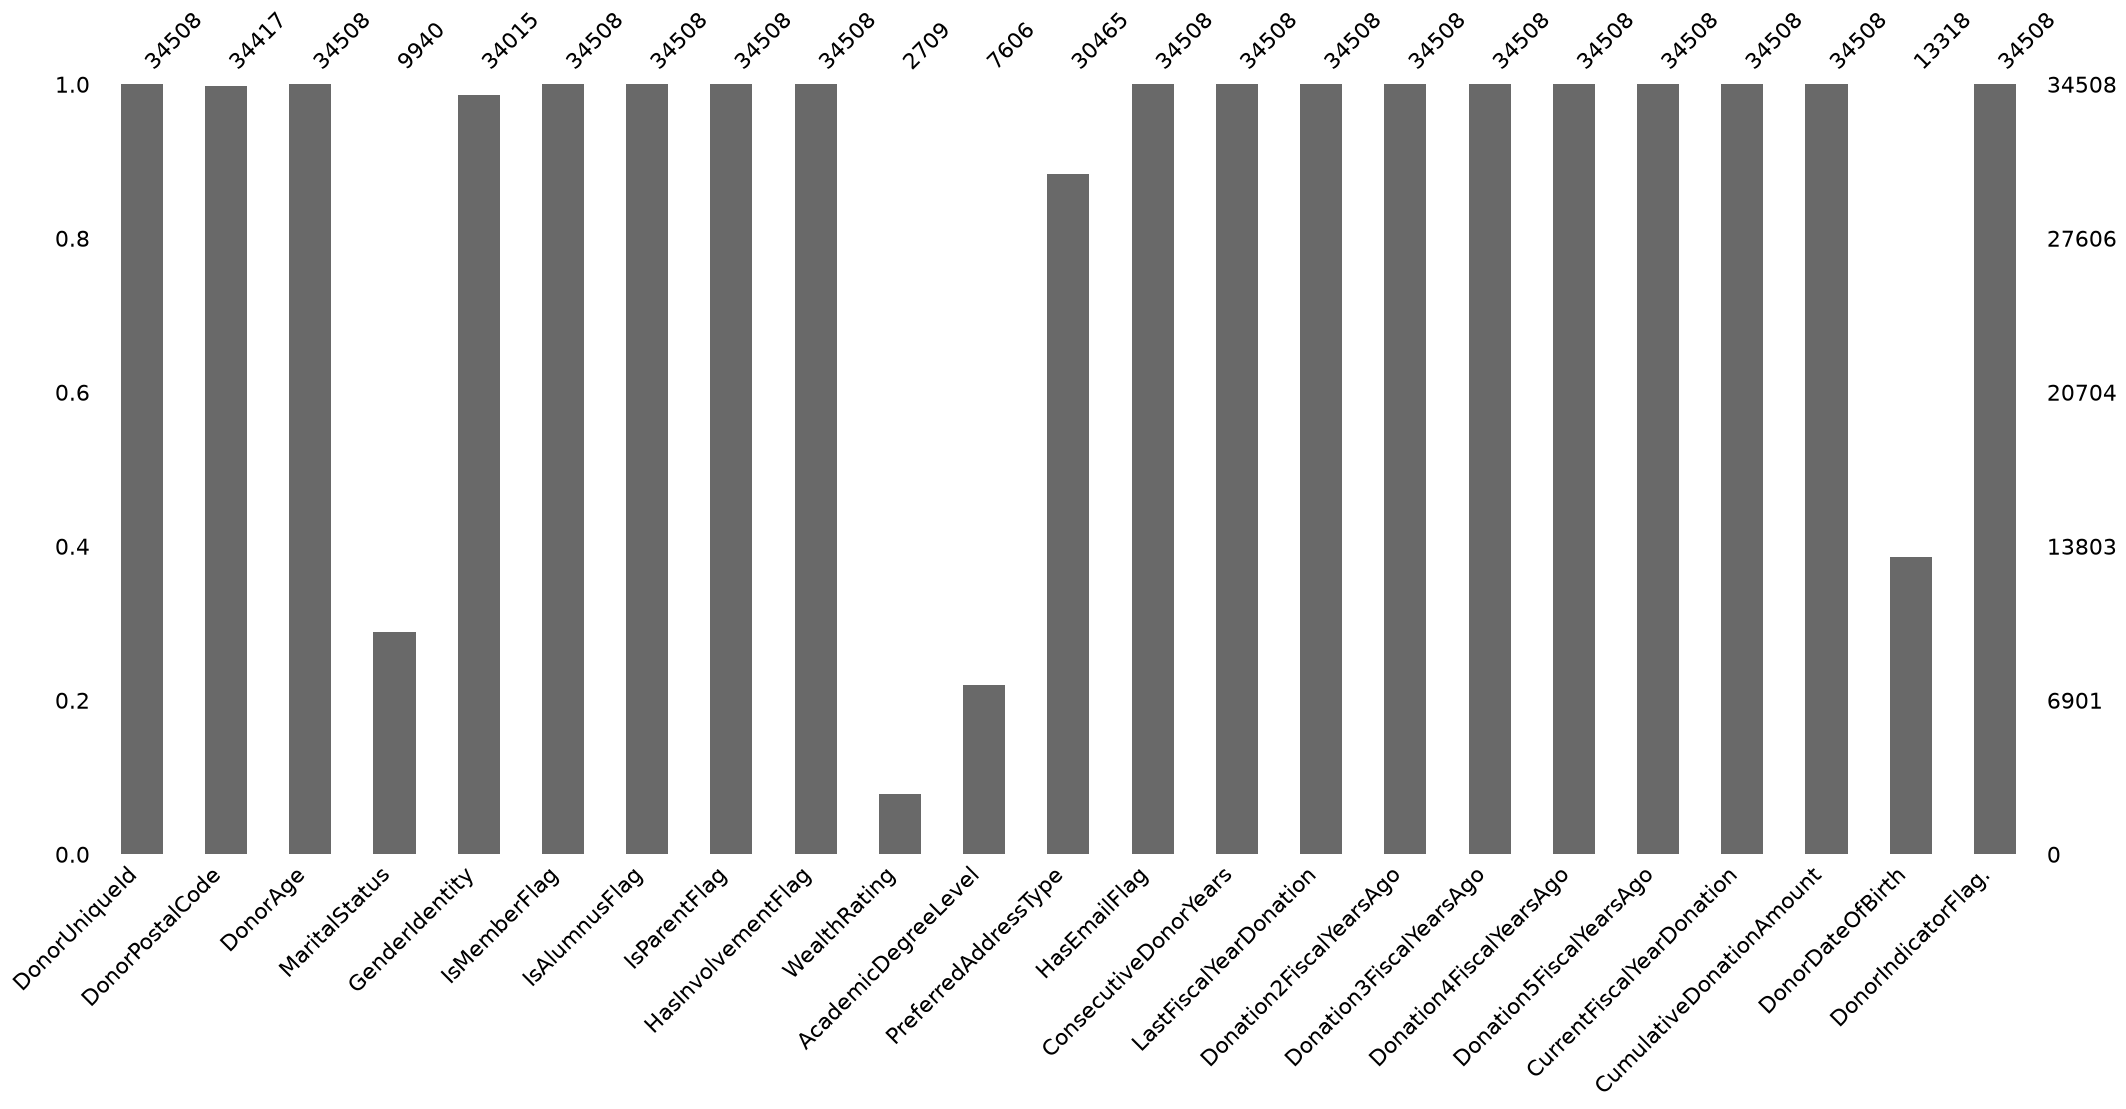

In [ ]:
# Code snippet 8
# Displaying missing data proportion
msno.bar(data)

In [ ]:
# Code snippet 9
# Dropping  'MaritalStatus', 'WealthRating', 'AcademicDegreeLevel', 'DonorDateOfBirth' because of missing more than 20% data
# Quantitative Data Preparation
data80 = data.drop(['MaritalStatus', 'WealthRating', 'AcademicDegreeLevel', 'DonorDateOfBirth'], axis=1)

# Display the data80 columns
data80.columns

Index(['DonorUniqueId', 'DonorPostalCode', 'DonorAge', 'GenderIdentity',
       'IsMemberFlag', 'IsAlumnusFlag', 'IsParentFlag', 'HasInvolvementFlag',
       'PreferredAddressType', 'HasEmailFlag', 'ConsecutiveDonorYears',
       'LastFiscalYearDonation', 'Donation2FiscalYearsAgo',
       'Donation3FiscalYearsAgo', 'Donation4FiscalYearsAgo',
       'Donation5FiscalYearsAgo', 'CurrentFiscalYearDonation',
       'CumulativeDonationAmount', 'DonorIndicatorFlag.'],
      dtype='str')

In [ ]:
# Code snippet 10
import pandas as pd

# Quantitative Data Preparation
data80 = data.drop(['MaritalStatus', 'WealthRating', 'AcademicDegreeLevel', 'DonorDateOfBirth'], axis=1)

donation_columns = [
    'LastFiscalYearDonation',
    'Donation2FiscalYearsAgo',
    'Donation3FiscalYearsAgo',
    'Donation4FiscalYearsAgo',
    'Donation5FiscalYearsAgo', # Corrected typo here
    'CurrentFiscalYearDonation'
]

for col in donation_columns:
    # Check if the column exists in data80 before attempting to process it
    if col in data80.columns:
        data80[col] = data80[col].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
        data80[col] = pd.to_numeric(data80[col], errors='coerce')
    else:
        print(f"Warning: Column '{col}' not found in data80. Skipping.")

# Display the data types to confirm the change
display(data80[donation_columns].dtypes)


LastFiscalYearDonation       int64
Donation2FiscalYearsAgo      int64
Donation3FiscalYearsAgo      int64
Donation4FiscalYearsAgo      int64
Donation5FiscalYearsAgo      int64
CurrentFiscalYearDonation    int64
dtype: object

In [ ]:
# Code snippet 11
# Displaying data80 size/shape
data80.shape

(34508, 19)

In [ ]:
# Code snippet 12
# Setting the datatype for DonorPostalCode as str
data80['DonorPostalCode'] = data80['DonorPostalCode'].astype(str)

In [ ]:
# Code snippet 13
# Dropping noise variables - 'DonorUniqueId'
# Qualitative Data Preparation
predictors = data80.drop(['DonorUniqueId'], axis=1)

# Display the predictors
predictors.columns

Index(['DonorPostalCode', 'DonorAge', 'GenderIdentity', 'IsMemberFlag',
       'IsAlumnusFlag', 'IsParentFlag', 'HasInvolvementFlag',
       'PreferredAddressType', 'HasEmailFlag', 'ConsecutiveDonorYears',
       'LastFiscalYearDonation', 'Donation2FiscalYearsAgo',
       'Donation3FiscalYearsAgo', 'Donation4FiscalYearsAgo',
       'Donation5FiscalYearsAgo', 'CurrentFiscalYearDonation',
       'CumulativeDonationAmount', 'DonorIndicatorFlag.'],
      dtype='str')

In [ ]:
# Code snippet 14
# Drop the 'CumulativeDonationAmount' column due to data leakage
if 'CumulativeDonationAmount' in predictors.columns:
    predictors = predictors.drop(columns=['CumulativeDonationAmount'])
    print(" 'CumulativeDonationAmount' column dropped.")
else:
    print(" 'CumulativeDonationAmount' column not found (already dropped or never existed).")

display(predictors.head())

 'CumulativeDonationAmount' column dropped.


,DonorPostalCode,DonorAge,GenderIdentity,IsMemberFlag,IsAlumnusFlag,IsParentFlag,HasInvolvementFlag,PreferredAddressType,HasEmailFlag,ConsecutiveDonorYears,LastFiscalYearDonation,Donation2FiscalYearsAgo,Donation3FiscalYearsAgo,Donation4FiscalYearsAgo,Donation5FiscalYearsAgo,CurrentFiscalYearDonation,DonorIndicatorFlag.
0,23187.0,42,Female,N,N,N,N,HOME,N,1,0,0,0,0,0,0,Y
1,77643.0,33,Female,N,Y,N,Y,NaN,Y,0,0,0,0,0,0,0,Y
2,NaN,42,Female,N,N,N,N,HOME,N,1,0,0,0,0,0,200,Y
3,47141.0,31,Female,N,Y,N,Y,HOME,Y,0,0,0,0,0,0,0,N
4,92555.0,68,Female,N,N,N,N,HOME,Y,0,0,0,0,0,0,0,Y


In [ ]:
# Code snippet 15
# Displaying predictors size/shape
predictors.shape

(34508, 17)

In [ ]:
# Code snippet 16
# Importing relevant statistical tests/modules from Dython
from dython.nominal import associations

/tmp/ipykernel_12926/2373267393.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in predictors_cleaned.select_dtypes(include='object').columns:


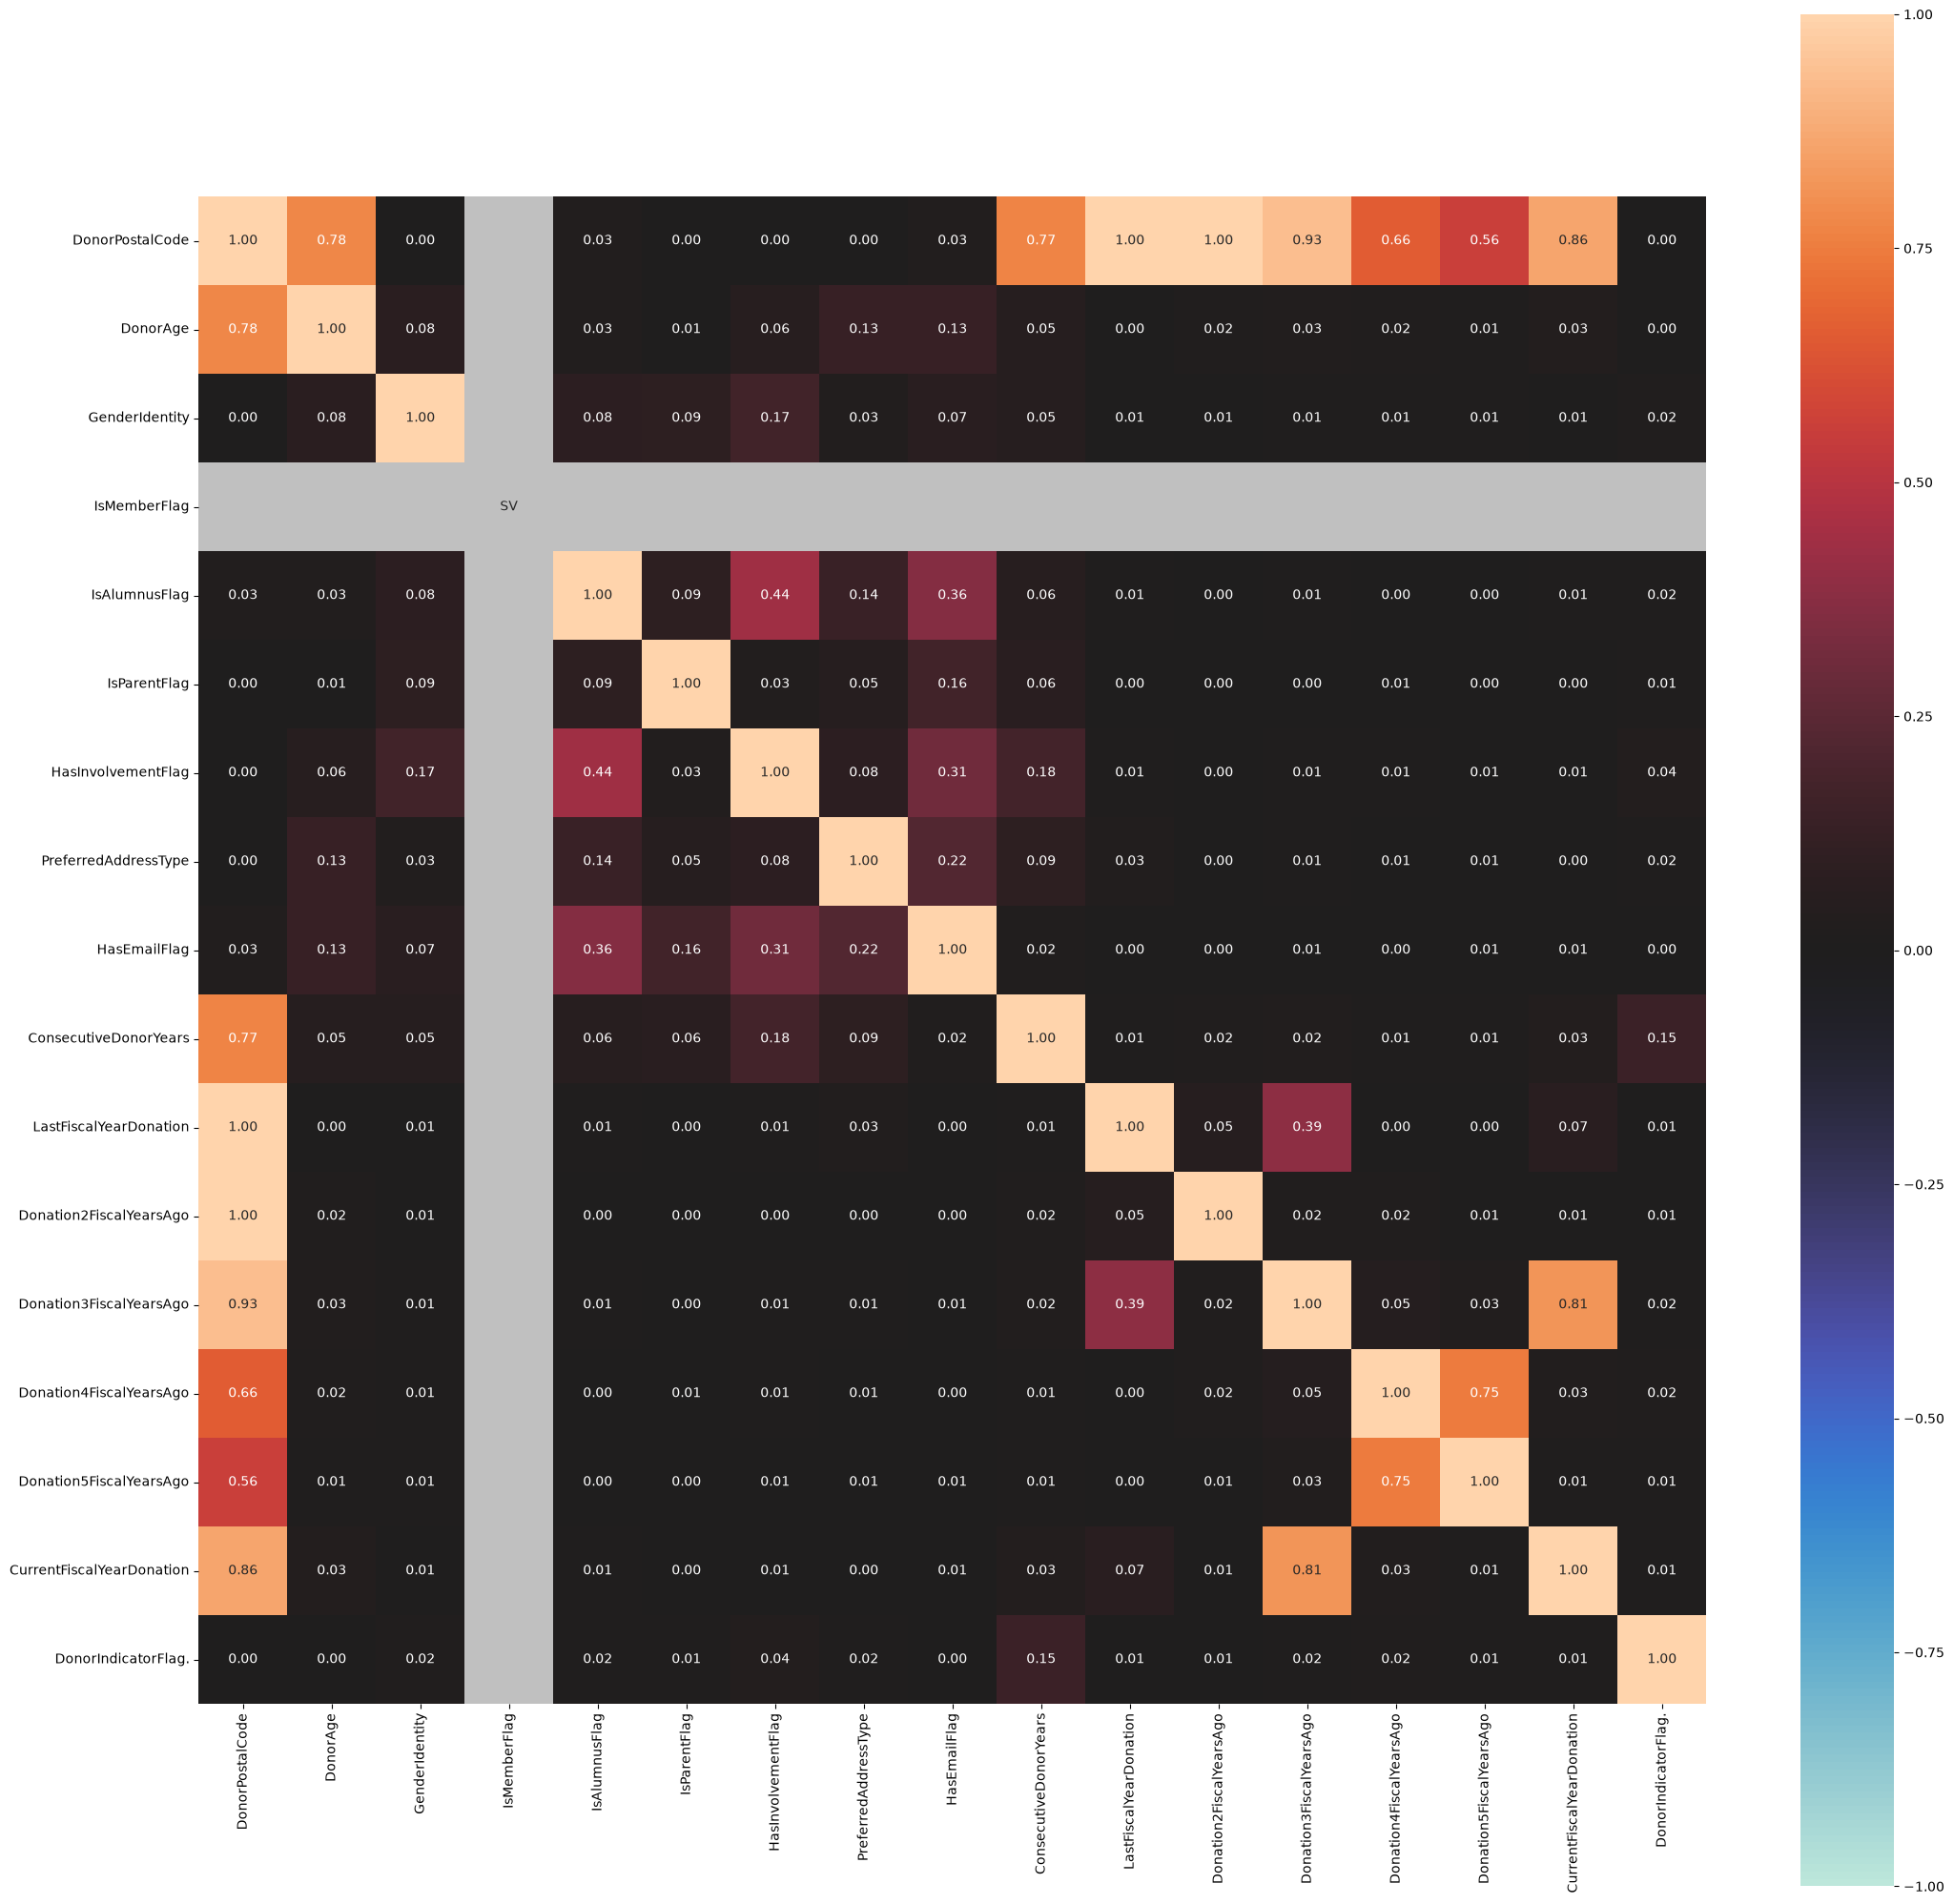

In [ ]:
# Code snippet 17
# Running the associations function on predictor variables

# Make a copy of predictors to perform NaN handling without altering the original DataFrame
predictors_cleaned = predictors.copy()

# Fill NaN values in object (string) columns with an empty string
for col in predictors_cleaned.select_dtypes(include='object').columns:
    predictors_cleaned[col] = predictors_cleaned[col].fillna('')

# Fill NaN values in numeric columns with 0
for col in predictors_cleaned.select_dtypes(include=['number']).columns:
    predictors_cleaned[col] = predictors_cleaned[col].fillna(0)

assoc = associations(predictors_cleaned)


In [ ]:
# Code snippet 18
# Storing the association values in a matrix
assoc_matrix = assoc['corr']

In [ ]:
# Code snippet 19
# Setting the target variable
target = 'DonorIndicatorFlag.'

In [ ]:
# Code snippet 20
# Listing the most impacting/associated variables with the target variable
assoc_matrix[target].abs().sort_values(ascending=False)

DonorIndicatorFlag.          1.000000
ConsecutiveDonorYears        0.147787
HasInvolvementFlag           0.036336
GenderIdentity               0.021286
Donation4FiscalYearsAgo      0.017195
PreferredAddressType         0.015475
IsAlumnusFlag                0.015293
Donation3FiscalYearsAgo      0.015172
Donation5FiscalYearsAgo      0.009827
CurrentFiscalYearDonation    0.009747
IsParentFlag                 0.007930
Donation2FiscalYearsAgo      0.007187
LastFiscalYearDonation       0.005457
DonorAge                     0.002013
HasEmailFlag                 0.001605
DonorPostalCode              0.000000
IsMemberFlag                 0.000000
Name: DonorIndicatorFlag., dtype: float64